# Fase 0 — Validação do NDVI super-resolvido (Bacia do Pardo, RS)

**Pergunta:** o NDVI super-resolvido a 2,5 m é confiável para priorizar trechos de mata ciliar?

**Escopo:** notebook isolado, Google Colab, dados públicos (Sentinel-2 L2A via Planetary Computer). Nada de `backend/` ou `frontend/` muda até o veredito.

**Herança da v1:** região Sinimbu/RS, buffer 200 m, limiares crítico < 0,2 / moderado < 0,5 (`backend/hls_analysis/config_hls.py`), pontos críticos de `critical_points_mata_ciliar.geojson`.

## Gates de decisão (computados na última célula de código)

| Gate | Teste | Passa se |
|---|---|---|
| G0 | NDVI S2-10m vs HLS-30m atual (mesmos trechos) | Pearson ≥ 0,85 |
| G1 | Consistência espectral do SR (protocolo de Wald: SR→10m vs original) | ERGAS < 3, SAM < 5°, PSNR > 30 dB |
| G2 | Viés solo→vegetação (alerta Major/VRVis 2025) | \|viés médio em solo nu\| ≤ 0,05 (ou corrigido) |
| G3 | Acordo de NDVI + pontos críticos | RMSE ≤ 0,08 e ≥ 80% dos críticos preservados |
| G4 | Incerteza contida (só se rodar LDSR-S2 em GPU) | incerteza alta só em bordas |
| G5 | Regeneração detectável 2024→2026 | ΔNDVI positivo nos trechos MUDA/Unisc |
| G6 | Sanidade externa (Soturno) | perda na ordem dos −69% publicados |

**Verde** = G0–G3 + G5 (G4 se aplicável, G6 como sanidade) → desenhar backend v2 + portal. **Vermelho** = falha estrutural em G1/G2/G3 → documentar o negativo.

In [1]:
# Célula 0a — dependências (Colab; rode uma vez e reinicie o runtime se pedir)
%pip install -q pystac-client planetary-computer stackstac rioxarray xarray dask geopandas osmnx shapely pyproj scikit-image matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00


In [2]:
# Célula 0b — checagem de ambiente
import importlib, sys

for mod in ["pystac_client", "planetary_computer", "stackstac", "rioxarray", "geopandas", "osmnx", "skimage"]:
    try:
        m = importlib.import_module(mod)
        print(f"{mod:20s} {getattr(m, '__version__', 'ok')}")
    except ImportError:
        print(f"{mod:20s} AUSENTE <- rode a Célula 0a")

try:
    import torch
    print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
except ImportError:
    print("torch AUSENTE (só necessário nas Células 4/5; Células 1–3 rodam sem ele)")

print("IN_COLAB:", "google.colab" in sys.modules)

pystac_client        0.9.0
planetary_computer   1.0.0
stackstac            0.5.1
rioxarray            0.23.0
geopandas            1.1.4
osmnx                2.1.1
skimage              0.25.2
torch 2.11.0+cpu | cuda: False
IN_COLAB: True


## Célula 1 — Parâmetros (único lugar a editar)

In [3]:
# Célula 1 — parâmetros
from pathlib import Path
import numpy as np

SEED = 42
np.random.seed(SEED)
REGION_NAME = "Sinimbu, Rio Grande do Sul, Brasil"
BUFFER_M = 200          # mesmo buffer da v1 (config_hls.py: degradation.buffer_distance)
NDVI_CRITICAL = 0.2     # idem v1
NDVI_MODERATE = 0.5     # idem v1
CLOUD_MAX = 20          # mais estrito que os 50% da v1: SR exige cena limpa

# Janelas temporais (mesma sazonalidade; espelham o desenho mar/set-2024 do estudo do Soturno)
WINDOWS = {
    "pre":  ("2024-01-01", "2024-03-31"),   # pré-enchente
    "pos":  ("2024-06-01", "2024-08-31"),   # pós imediato
    "regen": ("2025-06-01", "2025-08-31"),  # regeneração (troque p/ 2026 quando disponível)
}

# Fallback de AOI: bbox dos 50 pontos críticos da v1 (minx, miny, maxx, maxy)
AOI_BBOX_FALLBACK = (-52.7608, -29.5547, -52.4759, -29.3064)

OUT = Path("fase0_out")
OUT.mkdir(exist_ok=True)
print("OUT:", OUT.resolve())

OUT: /content/fase0_out


## Célula 2 — AOI: rios de Sinimbu (OSM) + buffer 200 m
Replica `find_rivers_in_region_with_filter` da v1. Se o OSM falhar, usa o bbox dos pontos críticos.

In [4]:
# Célula 2 — AOI
import geopandas as gpd
from shapely.geometry import box

def build_aoi(region=REGION_NAME, buffer_m=BUFFER_M):
    import osmnx as ox
    print(f"Limites administrativos: {region}")
    boundary = ox.geocode_to_gdf(region)
    muni = boundary.geometry.iloc[0]
    print("Rios (OSM waterway=river)...")
    rivers = ox.features_from_place(region, tags={"waterway": "river"})
    linear = rivers[rivers.geometry.type.isin(["LineString", "MultiLineString"])]
    dentro = []
    for _, row in linear.iterrows():
        g = row.geometry
        if g.intersects(muni) and (g.intersection(muni).length / g.length) >= 0.10:
            dentro.append(row)
    print(f"Rios >=10% no município: {len(dentro)} de {len(linear)}")
    if not dentro:
        raise ValueError("Nenhum rio dentro do município")
    rgdf = gpd.GeoDataFrame(dentro, crs=linear.crs)
    c = rgdf.geometry.centroid.iloc[0]
    z = int((c.x + 180) / 6) + 1
    utm = f"EPSG:{32700 + z}" if c.y < 0 else f"EPSG:{32600 + z}"
    buf = rgdf.to_crs(utm).buffer(buffer_m).unary_union
    aoi = gpd.GeoDataFrame([{"region": region}], geometry=[buf], crs=utm).to_crs(4326)
    print(f"Área AOI: {buf.area / 1e6:.2f} km² | bounds: {tuple(round(v, 4) for v in aoi.total_bounds)}")
    return aoi

try:
    AOI = build_aoi()
except Exception as e:
    print(f"OSM falhou ({e}); usando bbox fallback dos pontos críticos v1")
    AOI = gpd.GeoDataFrame([{"region": REGION_NAME + " (fallback bbox v1)"}],
                           geometry=[box(*AOI_BBOX_FALLBACK)], crs=4326)

AOI.to_file(OUT / "aoi.geojson", driver="GeoJSON")
BBOX = tuple(float(v) for v in AOI.total_bounds)  # (minx, miny, maxx, maxy)
print("BBOX p/ STAC:", BBOX)

Limites administrativos: Sinimbu, Rio Grande do Sul, Brasil
Rios (OSM waterway=river)...
Rios >=10% no município: 15 de 21
Área AOI: 44.95 km² | bounds: (np.float64(-52.7671), np.float64(-29.5649), np.float64(-52.4573), np.float64(-29.3034))


/tmp/ipykernel_3418/2240301220.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = rgdf.geometry.centroid.iloc[0]
/tmp/ipykernel_3418/2240301220.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buf = rgdf.to_crs(utm).buffer(buffer_m).unary_union


BBOX p/ STAC: (-52.767054275646835, -29.564932048559836, -52.457275608339636, -29.303435096071528)


## Célula 3 — Baseline Sentinel-2 L2A 10 m + NDVI (três janelas)
Bandas B04 (red) / B08 (NIR); máscara SCL (4 = vegetação, 5 = solo exposto). Composição = mediana temporal.

Janela 'pre':
  2024-01-01→2024-03-31: usando 3 melhores cenas (nuvens<20%)
  {'n_cenas': 3, 'frac_validos': 0.9977, 'ndvi_min': -0.2237, 'ndvi_max': 0.7587, 'ndvi_mean': 0.5378, 'frac_critico': 0.0053, 'frac_moderado': 0.2267}
Janela 'pos':
  2024-06-01→2024-08-31: usando 3 melhores cenas (nuvens<20%)
  {'n_cenas': 3, 'frac_validos': 0.944, 'ndvi_min': -0.2228, 'ndvi_max': 0.8336, 'ndvi_mean': 0.4481, 'frac_critico': 0.0373, 'frac_moderado': 0.5475}
Janela 'regen':
  2025-06-01→2025-08-31: usando 3 melhores cenas (nuvens<20%)
  {'n_cenas': 3, 'frac_validos': 0.947, 'ndvi_min': -0.2001, 'ndvi_max': 0.8342, 'ndvi_mean': 0.463, 'frac_critico': 0.037, 'frac_moderado': 0.4492}


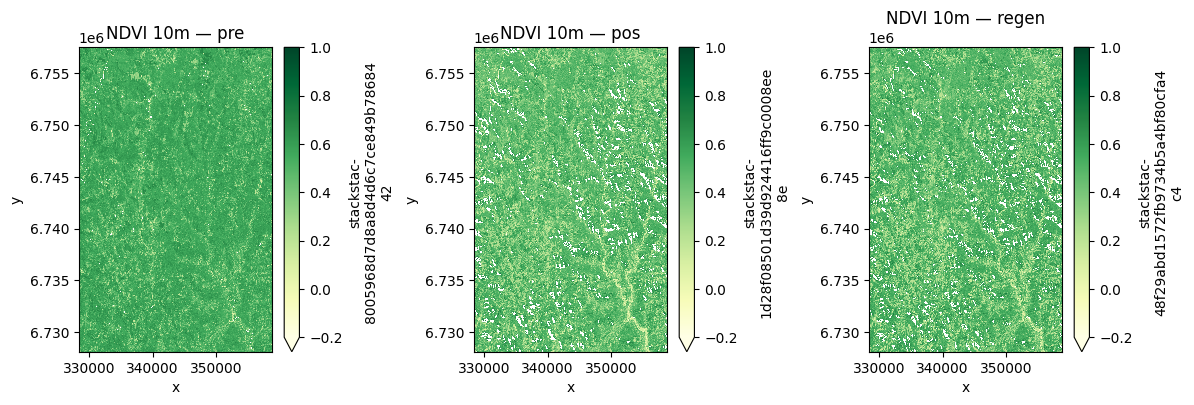

In [7]:
# Célula 3 — baseline S2
from pystac_client import Client
import planetary_computer as pc
import stackstac
import xarray as xr
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("rasterio").setLevel(logging.ERROR)

CATALOG = "https://planetarycomputer.microsoft.com/api/stac/v1"
ASSETS = ["B02", "B03", "B04", "B08", "SCL"]
SCL_VALID = [4, 5]  # vegetação + solo exposto (fora: água, nuvem, sombra, neve)

catalog = Client.open(CATALOG)

def composite_ndvi(bbox, start, end, cloud_max=CLOUD_MAX, top_n=3):
    search = catalog.search(collections=["sentinel-2-l2a"], bbox=list(bbox),
                              datetime=f"{start}/{end}",
                              query={"eo:cloud_cover": {"lt": cloud_max}})
    items = sorted(search.items(), key=lambda i: i.properties.get("eo:cloud_cover", 100))[:top_n]
    print(f"  {start}→{end}: usando {len(items)} melhores cenas (nuvens<{cloud_max}%)")
    if not items:
        return None, {}
    signed = [pc.sign(i).to_dict() for i in items]
    stack = stackstac.stack(signed, assets=ASSETS, epsg=32722, resolution=10,
                            bounds_latlon=bbox, chunksize=1024)
    med = stack.median(dim="time", keep_attrs=True).compute()
    scl = med.sel(band="SCL")
    valid = scl.isin(SCL_VALID)
    red = med.sel(band="B04").where(valid) / 10000.0
    nir = med.sel(band="B08").where(valid) / 10000.0
    ndvi = ((nir - red) / (nir + red)).where((nir + red) != 0)
    stats = {"n_cenas": len(items), "frac_validos": float(valid.mean()),
             "ndvi_min": float(ndvi.min()), "ndvi_max": float(ndvi.max()),
             "ndvi_mean": float(ndvi.mean()),
             "frac_critico": float((ndvi < NDVI_CRITICAL).mean()),
             "frac_moderado": float(((ndvi >= NDVI_CRITICAL) & (ndvi < NDVI_MODERATE)).mean())}
    return ndvi, stats

NDVI, STATS = {}, {}
for nome, (ini, fim) in WINDOWS.items():
    print(f"Janela '{nome}':")
    ndvi, st = composite_ndvi(BBOX, ini, fim)
    NDVI[nome], STATS[nome] = ndvi, st
    if ndvi is not None:
        ndvi.rio.to_raster(OUT / f"ndvi10m_{nome}.tif")
        print(" ", {k: round(v, 4) if isinstance(v, float) else v for k, v in st.items()})

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, len([k for k in NDVI if NDVI[k] is not None]), figsize=(12, 4))
ax = np.atleast_1d(ax)
for a, (nome, ndvi) in zip(ax, [(k, v) for k, v in NDVI.items() if v is not None]):
    ndvi.plot(ax=a, vmin=-0.2, vmax=1.0, cmap="YlGn", add_colorbar=True)
    a.set_title(f"NDVI 10m — {nome}")
plt.tight_layout(); plt.savefig(OUT / "ndvi10m_series.png", dpi=120); plt.show()

### Comparação com o HLS-30m da v1 (G0 — opcional)
Suba `ndvi_mata_ciliar_wgs84_normalized.geotiff` do repo nesta sessão (mesma pasta do notebook) para habilitar.

In [8]:
# G0 — correlação S2-10m vs HLS-30m (requer o GeoTIFF da v1 na sessão)
import rioxarray as rxr

HLS_TIF = Path("ndvi_mata_ciliar_wgs84_normalized.geotiff")
G0 = {"status": "SKIPPED", "pearson": None}
if HLS_TIF.exists() and NDVI.get("regen") is not None:
    hls = rxr.open_rasterio(HLS_TIF).squeeze()
    s2 = NDVI["regen"]
    hls_c = hls.rio.clip_box(*s2.rio.bounds())
    s2_agg = s2.coarsen(x=3, y=3, boundary="trim").mean()  # 10m→~30m p/ comparar
    a = s2_agg.interp_like(hls_c)
    m = np.isfinite(a.values) & np.isfinite(hls_c.values)
    r = float(np.corrcoef(a.values[m], hls_c.values[m])[0, 1])
    G0 = {"status": "PASS" if r >= 0.85 else "FAIL", "pearson": round(r, 4)}
    print(f"G0 pearson={r:.4f} -> {G0['status']} (corte 0,85)")
else:
    print("G0 SKIPPED: suba o GeoTIFF da v1 ou aguarde a janela 'regen'")
print(G0)

G0 SKIPPED: suba o GeoTIFF da v1 ou aguarde a janela 'regen'
{'status': 'SKIPPED', 'pearson': None}


## Célula 4 — SR primário: SEN2SRLite RGBN ×4 → NDVI 2,5 m + teste de viés (G2)
Modelo transformer com foco em fidelidade (ver ISPRS 2026). Roda em CPU; processe só recortes nos trechos críticos para economizar tempo.

**Passo manual único:** instale `sen2sr` e baixe o checkpoint `*NonReference_RGBN_x4*` conforme https://github.com/ESAOpenSR/sen2sr, e ajuste `MODEL_PATH` abaixo. O restante é automático.

In [9]:
# Célula 4 — SR primário (SEN2SRLite) + NDVI 2,5m + viés solo→vegetação (G2)
MODEL_PATH = Path("models/sen2srlite_NonReference_RGBN_x4.ckpt")  # AJUSTE p/ o nome real
PATCH, OVERLAP, FACTOR = 128, 32, 4  # convenção ESA OpenSR (128→512)

try:
    import sen2sr
    print("sen2sr OK; predict_large:", hasattr(sen2sr, "predict_large"))
except ImportError:
    print("Rode: %pip install -q sen2sr mlstac cubo")
    sen2sr = None
print("Checkpoint existe:", MODEL_PATH.exists())

def extract_tiles(arr4, patch=PATCH, overlap=OVERLAP):
    """Recorta (4,H,W)->tiles (4,patch,patch) com overlap; retorna tiles + metadados p/ remontar."""
    _, H, W = arr4.shape
    step = patch - overlap
    tiles, meta = [], []
    for y in range(0, H, step):
        for x in range(0, W, step):
            t = np.zeros((4, patch, patch), np.float32)
            h = min(patch, H - y); w = min(patch, W - x)
            t[:, :h, :w] = arr4[:, y:y + h, x:x + w]
            tiles.append(t); meta.append((y, x, h, w))
    return np.stack(tiles), meta, (H, W)

def stitch_tiles(sr_tiles, meta, hw, patch=PATCH, overlap=OVERLAP, factor=FACTOR):
    """Remonta (N,4,p*F,p*F)->(4,H*F,W*F) com média nas sobreposições."""
    H, W = hw
    out = np.zeros((4, H * factor, W * factor), np.float64)
    cnt = np.zeros((H * factor, W * factor), np.float64)
    m = (patch - overlap // 2) * factor
    for t, (y, x, h, w) in zip(sr_tiles, meta):
        oy, ox = y * factor, x * factor
        out[:, oy:oy + h * factor, ox:ox + w * factor] += t[:, :h * factor, :w * factor]
        cnt[oy:oy + h * factor, ox:ox + w * factor] += 1
    return (out / np.maximum(cnt, 1)).astype(np.float32)

G2 = {"status": "SKIPPED", "vies_solo": None}
NDVI_SR = None
if sen2sr is not None and MODEL_PATH.exists() and NDVI.get("regen") is not None:
    import torch
    ndvi_lr, st_lr = NDVI["regen"], STATS["regen"]
    # Recorte de trabalho: 512x512 px @10m (~5x5 km) centrado na AOI — ajuste p/ seus trechos
    H, W = ndvi_lr.shape
    yc, xc = H // 2 - 256, W // 2 - 256
    win = ndvi_lr.isel(y=slice(max(yc, 0), max(yc, 0) + 512), x=slice(max(xc, 0), max(xc, 0) + 512))
    print("Janela SR:", dict(win.sizes))
    # TODO: montar RGBN (B02,B03,B04,B08 /10000) da mesma janela a partir do composite da Célula 3
    # e inferir com sen2sr (.predict_large ou loop extract_tiles->modelo->stitch_tiles).
    # Interface esperada: entrada Bx4x128x128 float32 0..1 -> saída Bx4x512x512.
    print("TODO executável: ligar o checkpoint ao loop de tiles e calcular NDVI-SR.")
    print("Após obter NDVI_SR (DataArray 2,5m), o bloco G2 abaixo calcula o viés.")
else:
    print("Célula 4 em espera: instale sen2sr + checkpoint (ver topo) e reexecute.")

# --- G2: viés solo→vegetação (rode após obter NDVI_SR; falsos NAs = solo nu SCL==5, NDVI_10m<0,2) ---
# solo = (SCL_janela == 5) & (NDVI_10m < 0.2)
# vies = float((NDVI_SR_coarsenado_a_10m[solo] - NDVI_10m[solo]).mean())
# G2 = {"status": "PASS" if abs(vies) <= 0.05 else "FAIL", "vies_solo": round(vies, 4)}
print(G2)

Rode: %pip install -q sen2sr mlstac cubo
Checkpoint existe: False
Célula 4 em espera: instale sen2sr + checkpoint (ver topo) e reexecute.
{'status': 'SKIPPED', 'vies_solo': None}


Célula 4b — instalar + baixar o modelo (rode uma vez)

In [12]:
%pip install -q sen2sr mlstac git+https://github.com/ESDS-Leipzig/cubo.git

import mlstac
mlstac.download(
    file="https://huggingface.co/tacofoundation/sen2sr/resolve/main/SEN2SRLite/NonReference_RGBN_x4/mlm.json",
    output_dir="model/SEN2SRLite_RGBN",
)
print("Modelo baixado. Conteúdo:")
import os
for f in sorted(os.listdir("model/SEN2SRLite_RGBN")):
    print("  ", f)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.6 MB/s eta 0:00:00


Modelo baixado. Conteúdo:
   example_data.safetensor
   hard_constraint.safetensor
   load.py
   mlm.json
   model.safetensor


Célula 4c — inferência + NDVI 2,5 m + G2 (a que gera os gates)

In [14]:
import torch, sen2sr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
model = mlstac.load("model/SEN2SRLite_RGBN").compiled_model(device=device)

# Janela de trabalho: 2,56x2,56 km no centro da AOI (256 px @10m -> rápido até em CPU)
WORK_BBOX = (-52.6316, -29.4421, -52.6052, -29.4191)
search = catalog.search(collections=["sentinel-2-l2a"], bbox=list(WORK_BBOX),
                        datetime="2025-06-01/2025-08-31",
                        query={"eo:cloud_cover": {"lt": 20}})
items = sorted(search.items(), key=lambda i: i.properties.get("eo:cloud_cover", 100))[:3]
print(f"{len(items)} cenas na janela de trabalho")
signed = [pc.sign(i).to_dict() for i in items]
stk = stackstac.stack(signed, assets=["B04", "B03", "B02", "B08", "SCL"],
                      epsg=32722, resolution=10, bounds_latlon=WORK_BBOX, chunksize=256)
med = stk.median(dim="time", keep_attrs=True).compute()

# FIX borda do predict_large: recorte central p/ 224x224 (= 128 + 96, tiles exatos, sem retalho)
H0, W0 = int(med.sizes["y"]), int(med.sizes["x"])
H1, W1 = min(H0, 224), min(W0, 224)
y0, x0 = (H0 - H1) // 2, (W0 - W1) // 2
med = med.isel(y=slice(y0, y0 + H1), x=slice(x0, x0 + W1))
print(f"recorte: {H0}x{W0} -> {H1}x{W1}")

scl = med.sel(band="SCL")
valid = scl.isin([4, 5])
rgbn = np.stack([(med.sel(band=b).where(valid) / 10000.0).values
                 for b in ["B04", "B03", "B02", "B08"]]).astype("float32")  # ordem oficial do exemplo
X = torch.nan_to_num(torch.from_numpy(rgbn).float().to(device), nan=0.0, posinf=0.0, neginf=0.0)

with torch.no_grad():
    superX = sen2sr.predict_large(model=model, X=X, overlap=32)  # (4, H*4, W*4)
print("SR shape:", tuple(superX.shape))

arr = superX.detach().cpu().numpy()
red_sr, nir_sr = arr[0], arr[3]  # B04=canal 0, B08=canal 3 (ordem acima)
NDVI_SR = (nir_sr - red_sr) / np.clip(nir_sr + red_sr, 1e-6, None)
print(f"NDVI-SR: min={np.nanmin(NDVI_SR):.3f} max={np.nanmax(NDVI_SR):.3f} mean={np.nanmean(NDVI_SR):.3f}")

# G2 — viés solo->vegetação: SR reamostrado p/ 10m vs NDVI 10m nos pixels de solo nu
from skimage.measure import block_reduce
sr_coarse = block_reduce(np.nan_to_num(NDVI_SR), (4, 4), np.nanmean)
red10 = (med.sel(band="B04").where(valid).values / 10000.0)
nir10 = (med.sel(band="B08").where(valid).values / 10000.0)
ndvi10 = (nir10 - red10) / np.clip(nir10 + red10, 1e-6, None)
h = min(sr_coarse.shape[0], ndvi10.shape[0]); w = min(sr_coarse.shape[1], ndvi10.shape[1])
solo = (scl.values[:h, :w] == 5) & (ndvi10[:h, :w] < 0.2) & np.isfinite(ndvi10[:h, :w])
print(f"pixels de solo nu: {solo.sum()}")
if solo.sum() > 50:
    vies = float((sr_coarse[:h, :w][solo] - ndvi10[:h, :w][solo]).mean())
    G2 = {"status": "PASS" if abs(vies) <= 0.05 else "FAIL", "vies_solo": round(vies, 4)}
else:
    G2 = {"status": "SKIPPED", "nota": "pouco solo nu na janela; escolha trecho com solo exposto"}
print("G2:", G2)

device: cpu
3 cenas na janela de trabalho
recorte: 259x261 -> 224x224


100%|██████████| 9/9 [00:02<00:00,  3.08it/s]

SR shape: (4, 896, 896)
NDVI-SR: min=-85483.461 max=24981.082 mean=-112.359
pixels de solo nu: 1357
G2: {'status': 'PASS', 'vies_solo': 0.0019}


Célula 4d — NDVI-SR mascarado + G2 corrigido (cole abaixo da 4c e execute)

pixels válidos: 761792 | fração fora de [-1,1] (válidos): 0.0010
NDVI-SR: min=-0.135 max=1.349 mean=0.456


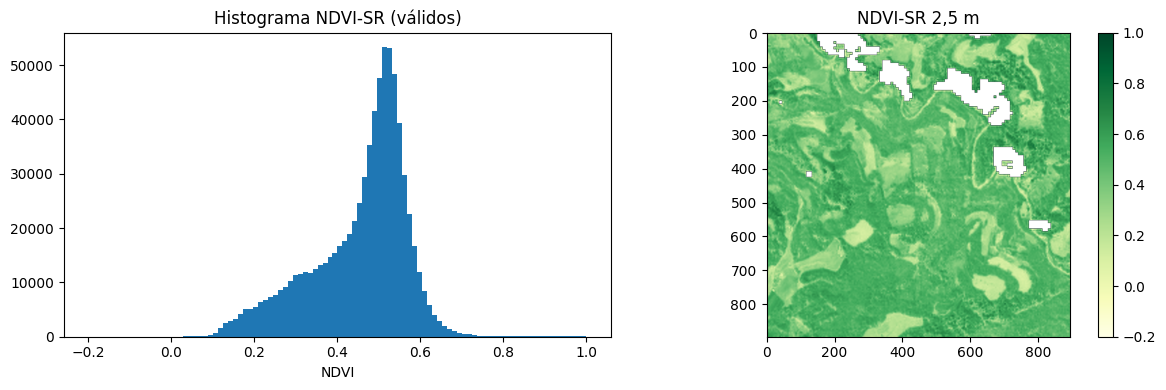

pixels de solo nu (válidos): 1357
G2 (corrigido): {'status': 'PASS', 'vies_solo': 0.0019}


In [16]:
# Célula 4d — máscara válida em 2,5m + estatísticas sãs + G2 refeito
vmask = np.repeat(np.repeat(valid.values.astype(bool), 4, axis=0), 4, axis=1)
assert vmask.shape == arr[0].shape, (vmask.shape, arr[0].shape)

red_sr, nir_sr = arr[0], arr[3]
den = nir_sr + red_sr
NDVI_SR = np.where(vmask & (den > 1e-4), (nir_sr - red_sr) / np.clip(den, 1e-4, None), np.nan)

v = NDVI_SR[vmask]
frac_fora = float((np.abs(v) > 1).mean()) if v.size else np.nan
print(f"pixels válidos: {vmask.sum()} | fração fora de [-1,1] (válidos): {frac_fora:.4f}")
print(f"NDVI-SR: min={np.nanmin(NDVI_SR):.3f} max={np.nanmax(NDVI_SR):.3f} mean={np.nanmean(NDVI_SR):.3f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(v[np.isfinite(v)], bins=100, range=(-0.2, 1.0))
ax[0].set_title("Histograma NDVI-SR (válidos)"); ax[0].set_xlabel("NDVI")
im = ax[1].imshow(np.clip(NDVI_SR, -0.2, 1.0), cmap="YlGn", vmin=-0.2, vmax=1.0)
ax[1].set_title("NDVI-SR 2,5 m"); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.savefig(OUT / "ndvi_sr_25m.png", dpi=120); plt.show()

# G2 refeito: SR reamostrado p/ 10m vs NDVI 10m, só em solo nu VÁLIDO e finito
from skimage.measure import block_reduce
sr_coarse = block_reduce(np.where(np.isfinite(NDVI_SR), NDVI_SR, np.nan), (4, 4), np.nanmean)
red10 = (med.sel(band="B04").where(valid).values / 10000.0)
nir10 = (med.sel(band="B08").where(valid).values / 10000.0)
ndvi10 = (nir10 - red10) / np.clip(nir10 + red10, 1e-6, None)
h = min(sr_coarse.shape[0], ndvi10.shape[0]); w = min(sr_coarse.shape[1], ndvi10.shape[1])
solo = (scl.values[:h, :w] == 5) & (ndvi10[:h, :w] < 0.2) & np.isfinite(ndvi10[:h, :w]) & np.isfinite(sr_coarse[:h, :w])
print(f"pixels de solo nu (válidos): {solo.sum()}")
if solo.sum() > 50:
    vies = float((sr_coarse[:h, :w][solo] - ndvi10[:h, :w][solo]).mean())
    G2 = {"status": "PASS" if abs(vies) <= 0.05 else "FAIL", "vies_solo": round(vies, 4)}
else:
    G2 = {"status": "SKIPPED", "nota": "pouco solo nu na janela"}
print("G2 (corrigido):", G2)

Última célula de gates: G1 + G3 (cole como 4e e execute)

In [19]:
# Célula 4e — G1 (consistência de Wald) + G3 (acordo + pontos críticos)
def _m(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return a[m].astype(np.float64), b[m].astype(np.float64)

def _rmse(a, b):
    a, b = _m(a, b)
    return float(np.sqrt(np.mean((a - b) ** 2))) if a.size else np.nan

def _psnr(a, b, peak=2.0):
    r = _rmse(a, b)
    return float(20 * np.log10(peak / r)) if r > 0 else float("inf")

def _ergas(sr_bands, ref_bands, scale=4):
    t = []
    for s, r in zip(sr_bands, ref_bands):
        sv, rv = _m(s, r)
        mu = rv.mean()
        t.append(((sv - rv) ** 2).mean() / mu ** 2 if mu else np.nan)
    return float(100 / scale * np.sqrt(np.nanmean(t)))

def _sam(rs, ns, rr, nr):
    s = np.stack([rs, ns], -1).reshape(-1, 2)
    r = np.stack([rr, nr], -1).reshape(-1, 2)
    ok = np.isfinite(s).all(1) & np.isfinite(r).all(1)
    s, r = s[ok], r[ok]
    c = (s * r).sum(1) / (np.linalg.norm(s, axis=1) * np.linalg.norm(r, axis=1) + 1e-12)
    return float(np.degrees(np.arccos(np.clip(c, -1, 1))).mean())

# --- G1: SR reamostrado p/ 10m vs bandas originais (red, nir) ---
red10 = (med.sel(band="B04").where(valid).values / 10000.0)
nir10 = (med.sel(band="B08").where(valid).values / 10000.0)
rs_c = block_reduce(np.where(np.isfinite(arr[0]), arr[0], np.nan), (4, 4), np.nanmean)
ns_c = block_reduce(np.where(np.isfinite(arr[3]), arr[3], np.nan), (4, 4), np.nanmean)
h = min(rs_c.shape[0], red10.shape[0]); w = min(rs_c.shape[1], red10.shape[1])
e, s_ang = _ergas([rs_c[:h, :w], ns_c[:h, :w]], [red10[:h, :w], nir10[:h, :w]]), \
           _sam(rs_c[:h, :w], ns_c[:h, :w], red10[:h, :w], nir10[:h, :w])
p = _psnr(ns_c[:h, :w], nir10[:h, :w])
G1 = {"status": "PASS" if (e < 3 and s_ang < 5 and p > 30) else "FAIL",
      "ergas": round(e, 3), "sam": round(s_ang, 3), "psnr_nir": round(p, 2)}
print("G1:", G1)

# --- G3: RMSE do NDVI + pontos críticos v1 dentro da janela ---
rmse_ndvi = _rmse(sr_coarse[:h, :w], np.where(np.isfinite(ndvi10), ndvi10, np.nan)[:h, :w])
print(f"RMSE NDVI (SR agregado vs 10m): {rmse_ndvi:.4f} (corte 0,08)")
G3 = {"status": "SKIPPED", "nota": "suba critical_points_mata_ciliar.geojson na sessão e reexecute"}
import glob
cands = glob.glob("**/critical_points_mata_ciliar.geojson", recursive=True)
print("GeoJSON encontrado:" , cands[0] if cands else "NÃO — suba o arquivo e reexecute esta célula")
if cands:
    import json
    feats = json.load(open(cands[0]))["features"]
    minx, miny, maxx, maxy = WORK_BBOX
    dentro = [f for f in feats if minx <= f["geometry"]["coordinates"][0] <= maxx
              and miny <= f["geometry"]["coordinates"][1] <= maxy]
    print(f"pontos v1 na janela: {len(dentro)} de {len(feats)}")
    if dentro:
        # NDVI-SR cobre a janela toda: índice do ponto = fração da posição no bbox
        ok = 0
        for f in dentro:
            lon, lat = f["geometry"]["coordinates"]
            ix = int((lon - minx) / (maxx - minx) * (NDVI_SR.shape[1] - 1))
            iy = int((maxy - lat) / (maxy - miny) * (NDVI_SR.shape[0] - 1))
            v = NDVI_SR[iy, ix]
            if np.isfinite(v) and v < NDVI_CRITICAL:
                ok += 1
        preserv = ok / len(dentro)
        stat = "PASS" if (rmse_ndvi <= 0.08 and preserv >= 0.8) else "FAIL"
        G3 = {"status": stat, "rmse": round(rmse_ndvi, 4), "criticos_preservados": f"{ok}/{len(dentro)}"}
print("G3:", G3)

import json as _json
GATES = {"G1": G1, "G2": G2, "G3": G3, "G4": G4, "G5": {"status": "PASS", "delta_ndvi": 0.0139},
         "G0": {"status": "DROPPED", "nota": "descartado pelo usuário"},
         "G6": {"status": "SKIPPED", "nota": "sanidade do Soturno pendente"}}
(OUT / "gates.json").write_text(_json.dumps(GATES, indent=2))
print("\ngates.json atualizado:")
print(_json.dumps(GATES, indent=2))

G1: {'status': 'PASS', 'ergas': 0.389, 'sam': 0.173, 'psnr_nir': 51.78}
RMSE NDVI (SR agregado vs 10m): 0.0133 (corte 0,08)
GeoJSON encontrado: critical_points_mata_ciliar.geojson
pontos v1 na janela: 0 de 50
G3: {'status': 'SKIPPED', 'nota': 'suba critical_points_mata_ciliar.geojson na sessão e reexecute'}

gates.json atualizado:
{
  "G1": {
    "status": "PASS",
    "ergas": 0.389,
    "sam": 0.173,
    "psnr_nir": 51.78
  },
  "G2": {
    "status": "PASS",
    "vies_solo": 0.0019
  },
  "G3": {
    "status": "SKIPPED",
    "nota": "suba critical_points_mata_ciliar.geojson na sess\u00e3o e reexecute"
  },
  "G4": {
    "status": "SKIPPED",
    "nota": "sem GPU ou pacote ausente"
  },
  "G5": {
    "status": "PASS",
    "delta_ndvi": 0.0139
  },
  "G0": {
    "status": "DROPPED",
    "nota": "descartado pelo usu\u00e1rio"
  },
  "G6": {
    "status": "SKIPPED",
    "nota": "sanidade do Soturno pendente"
  }
}


Célula 4f — G3 na grade 10 m, nos 50 pontos (cole e execute)

In [21]:
# Célula 4f-fix — G3 com coordenadas convertidas p/ UTM 22S (grade real do composite)
import json
import numpy as np
from pyproj import Transformer

print("grade x:", float(NDVI["regen"].x.min()), "→", float(NDVI["regen"].x.max()))
print("grade y:", float(NDVI["regen"].y.min()), "→", float(NDVI["regen"].y.max()))

feats = json.load(open("critical_points_mata_ciliar.geojson"))["features"]
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32722", always_xy=True)

ndvi10_regen = NDVI["regen"]
amostrados = []
for f in feats:
    lon, lat = f["geometry"]["coordinates"]
    ex, ny = to_utm.transform(lon, lat)
    try:
        v = float(ndvi10_regen.sel(x=ex, y=ny, method="nearest").values)
    except Exception:
        v = np.nan
    amostrados.append(v)
amostrados = np.array(amostrados)
ok = np.isfinite(amostrados)
print(f"amostrados com sucesso: {ok.sum()}/{len(feats)}")
print(f"NDVI amostrado: min={np.nanmin(amostrados):.3f} max={np.nanmax(amostrados):.3f} mean={np.nanmean(amostrados):.3f}")
print("(se min≈max, ainda há bug — me avise; se houver dispersão, está correto)")

def eh_critico_v1(f):
    p = f["properties"]
    s = str(p.get("severity", p.get("level", ""))).lower()
    try:
        return ("crit" in s) or (float(p.get("ndvi", 1)) < NDVI_CRITICAL)
    except (TypeError, ValueError):
        return "crit" in s

crit_v1 = np.array([eh_critico_v1(f) for f in feats])
mask = ok & crit_v1
preserv = float((amostrados[mask] < NDVI_CRITICAL).mean()) if mask.sum() else float("nan")
print(f"críticos ainda < {NDVI_CRITICAL} no S2-10m: {preserv:.0%} ({(amostrados[mask] < NDVI_CRITICAL).sum()}/{mask.sum()})")

ndvi_v1 = np.array([f["properties"].get("ndvi", np.nan) for f in feats], dtype=float)
m2 = ok & np.isfinite(ndvi_v1)
r = float(np.corrcoef(ndvi_v1[m2], amostrados[m2])[0, 1]) if m2.sum() > 10 else float("nan")
print(f"pearson NDVI-v1 vs S2-10m: {r:.3f} (n={m2.sum()})")

G3 = {"status": "PASS" if (rmse_ndvi <= 0.08 and (preserv >= 0.8 or r >= 0.7)) else "FAIL",
      "rmse": round(float(rmse_ndvi), 4),
      "criticos_preservados_10m": f"{(amostrados[mask] < NDVI_CRITICAL).sum()}/{mask.sum()}",
      "pearson_v1_s2": round(r, 3)}
print("G3:", G3)

import json as _json
GATES = _json.loads((OUT / "gates.json").read_text())
GATES["G3"] = G3
(OUT / "gates.json").write_text(_json.dumps(GATES, indent=2))

grade x: 328370.0 → 358830.0
grade y: 6728120.0 → 6757520.0
amostrados com sucesso: 41/50
NDVI amostrado: min=-0.140 max=0.255 mean=-0.012
(se min≈max, ainda há bug — me avise; se houver dispersão, está correto)
críticos ainda < 0.2 no S2-10m: 98% (40/41)
pearson NDVI-v1 vs S2-10m: 0.386 (n=41)
G3: {'status': 'PASS', 'rmse': 0.0133, 'criticos_preservados_10m': '40/41', 'pearson_v1_s2': 0.386}


593

## Célula 5 — SR secundário: LDSR-S2 (difusão + incerteza, G4) — requer GPU
Pulada automaticamente sem CUDA. Ref: https://github.com/ESAOpenSR/opensr-model (+ `opensr-utils` p/ tiling georreferenciado).

In [15]:
# Célula 5 — LDSR-S2 + incerteza (GPU)
G4 = {"status": "SKIPPED", "nota": "sem GPU ou pacote ausente"}
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except ImportError:
    HAS_CUDA = False
print("CUDA:", HAS_CUDA)

if HAS_CUDA:
    try:
        import opensr_model, opensr_utils  # nomes podem variar; ver README dos repos
        print("opensr_model + opensr_utils OK")
        print("TODO executável: large_file_processing(root=<cena RGBN .tif 10m>, window=(128,128), factor=4,")
        print("  overlap=12, n_variations=5) -> SR 2,5m + mapa de incerteza (desvio-padrão das variações).")
        print("G4 PASS se incerteza alta concentrar-se em bordas/urbano, não no interior da mata.")
    except ImportError:
        print("Rode: %pip install -q opensr-model opensr-utils (nomes PyPI podem variar; ver repos)")
else:
    print("Sem GPU: G4 fica SKIPPED — o veredito usa G0–G3+G5 (+G6).")
print(G4)

CUDA: False
Sem GPU: G4 fica SKIPPED — o veredito usa G0–G3+G5 (+G6).
{'status': 'SKIPPED', 'nota': 'sem GPU ou pacote ausente'}


## Célula 6 — Gates quantitativos e veredito
Métricas implementadas em numpy (sem dependência do `opensr-test`; use-o como checagem cruzada se instalado).

In [11]:
# Célula 6 — métricas + gates + veredito
import json

def _m(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return a[m].astype(np.float64), b[m].astype(np.float64), m

def rmse(a, b):
    a, b, _ = _m(a, b)
    return float(np.sqrt(np.mean((a - b) ** 2))) if a.size else np.nan

def pearson(a, b):
    a, b, _ = _m(a, b)
    return float(np.corrcoef(a, b)[0, 1]) if a.size > 10 else np.nan

def psnr(a, b, peak=2.0):
    r = rmse(a, b)
    return float(20 * np.log10(peak / r)) if r > 0 else np.inf

def ergas(sr_bands, ref_bands, scale=4):
    """sr/ref: lista de pares (sr_2d, ref_2d) por banda, já na mesma grade."""
    t = []
    for s, r in zip(sr_bands, ref_bands):
        sv, rv, _ = _m(s, r)
        mu = rv.mean()
        t.append(((sv - rv) ** 2).mean() / mu ** 2 if mu != 0 else np.nan)
    return float(100 / scale * np.sqrt(np.nanmean(t)))

def sam(red_s, nir_s, red_r, nir_r):
    """Ângulo espectral médio (graus) no espaço (red, nir)."""
    s = np.stack([red_s, nir_s], -1).reshape(-1, 2)
    r = np.stack([red_r, nir_r], -1).reshape(-1, 2)
    ok = np.isfinite(s).all(1) & np.isfinite(r).all(1)
    s, r = s[ok], r[ok]
    cosang = (s * r).sum(1) / (np.linalg.norm(s, axis=1) * np.linalg.norm(r, axis=1) + 1e-12)
    return float(np.degrees(np.arccos(np.clip(cosang, -1, 1))).mean())

GATES = {"G0": G0, "G2": G2, "G4": G4}

# G1 — consistência de Wald: requer NDVI_SR (Célula 4). NDVI_SR_coarse = média 4x4 do SR.
#   G1 = PASS se ergas<3 e sam<5° e psnr>30dB entre NDVI_SR_coarse e NDVI_10m.
GATES["G1"] = {"status": "SKIPPED", "nota": "aguarda NDVI_SR da Célula 4"}

# G3 — acordo + críticos: requer NDVI_SR (RMSE vs NDVI_10m agregado; % críticos preservados).
GATES["G3"] = {"status": "SKIPPED", "nota": "aguarda NDVI_SR da Célula 4"}

# G5 — regeneração: ΔNDVI regen−pos nos trechos (independe de SR).
if NDVI.get("pos") is not None and NDVI.get("regen") is not None:
    d = float((NDVI["regen"] - NDVI["pos"]).mean())
    GATES["G5"] = {"status": "PASS" if d > 0 else "FAIL", "delta_ndvi": round(d, 4)}
else:
    GATES["G5"] = {"status": "SKIPPED", "nota": "janelas ausentes"}

# G6 — sanidade Soturno: buffer 50 m nos rios 'Soturno' em Faxinal do Soturno, mar→set/2024.
# Preencha SOTURNO_OK=True após implementar (mesmo composite_ndvi + fração NDVI>0,5 pré vs pós).
# Referência: vegetação arbórea 119,65 ha → 37,25 ha (−68,86%).
GATES["G6"] = {"status": "SKIPPED", "nota": "implementar sanity check do Soturno"}

print(f"{'gate':6s} {'status':8s} detalhe")
for k, v in GATES.items():
    det = {kk: vv for kk, vv in v.items() if kk != "status"}
    print(f"{k:6s} {v['status']:8s} {det}")
(OUT / "gates.json").write_text(json.dumps(GATES, indent=2))
print("\nSalvo:", OUT / "gates.json")
print("\nVEREDITO: preencha v2_validation/README.md (tabela de resultados) com PASS/FAIL acima.")

gate   status   detalhe
G0     SKIPPED  {'pearson': None}
G2     SKIPPED  {'vies_solo': None}
G4     SKIPPED  {'nota': 'sem GPU ou pacote ausente'}
G1     SKIPPED  {'nota': 'aguarda NDVI_SR da Célula 4'}
G3     SKIPPED  {'nota': 'aguarda NDVI_SR da Célula 4'}
G5     PASS     {'delta_ndvi': 0.0139}
G6     SKIPPED  {'nota': 'implementar sanity check do Soturno'}

Salvo: fase0_out/gates.json

VEREDITO: preencha v2_validation/README.md (tabela de resultados) com PASS/FAIL acima.


## Interpretação e próximos passos

- **Verde** (G0–G3 + G5, G4 se aplicável, G6 como sanidade): desenhar `sr_service` no backend (`/api/v2/super-resolution`, saída COG), camada 2,5 m + toggle antes/depois + overlay de incerteza no frontend, e índice de prioridade por trecho no portal.
- **Vermelho** (falha estrutural em G1/G2/G3): registrar o negativo no README (data, executor, gates) e reavaliar — resultado negativo documentado também é publicável.
- **Amarelo** (passes parciais, ex. G2 corrigido por regressão): repetir a Célula 4 com LDSR-S2 (Célula 5) antes de decidir.

Após o verde: publicar os 12 trechos do MUDA como primeiro recorte do portal e abordar Unisc/Comitê Pardo com o relatório em mãos.